In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import argparse
import sys
from tqdm import tqdm

import src.utils.utils as utils
import src.training.training as training
import src.utils.extractor as extractor
import src.models.models as models
import src.models.foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
else:
    print(f"{torch.cuda.is_available()}")
    dev = "cpu"

In [33]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
Y_flat = utils.normalize(Y_flat)
E = torch.tensor(data["E"])
A_flat = torch.tensor(data["A"])
B, c, N = E.shape[0], E.shape[1], Y_flat.shape[1]

Y = utils.oneD_to_2d(Y_flat)
A = utils.oneD_to_2d(A_flat)
B = Y.shape[0]
H = Y.shape[-1]
Y = Y.to(torch.float32)
Y = Y.unsqueeze(0)

with open(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}_wavelength", "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [34]:
n_features = 9
use_cls = False
fm_name = "DOFA"
n_features = 4 if fm_name == "HyperSIGMA" else n_features
patch_size = 16

if fm_name == "DOFA":
    if H < 224:
        Y = F.interpolate(Y, size=(224,224))
    else:
        H = 224
    Y = Y[:,:,:224, :224]
    fm = rsfm.create_fm(fm_name, Y, n_features=n_features, use_cls=use_cls)
    features = rsfm.get_dofa_features(fm, Y, wavelengths)
    if use_cls:
        D = features.shape[-1]
    else:
        D = int(features.shape[0]/n_features)
        
elif fm_name == "HyperFree":
    n_features = 1
    use_cls = False
    n_patches = H//patch_size
    if n_patches%2 != 0:
        H = (n_patches-1)*patch_size + patch_size-1
    Y = Y[:, :, :H, :H]
    fm = rsfm.create_fm(fm_name, Y, patch_size=patch_size)
    features = rsfm.get_hyperfree_features(fm, Y, wavelengths)
    D = features.shape[0]

elif fm_name == "HyperSIGMA":
    fm = rsfm.create_fm(fm_name, Y, c)
    features = rsfm.get_hypersigma_features(fm, Y)
    D = int(features.shape[1]/n_features)

else:
    pass

if fm_name == "DOFA" or fm_name == "HyperFree":
    alpha = int(features.shape[1]**0.5)
    unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=n_features, use_cls=use_cls)

elif fm_name == "HyperSIGMA":
    patch_size=64
    unmixer = rsfm.Unmixing_from_features(D=D, B=B, c=c, H=patch_size, n_features=n_features, hypersig=True)

else:
    pass

The unmixer model has :  88.566238 M params


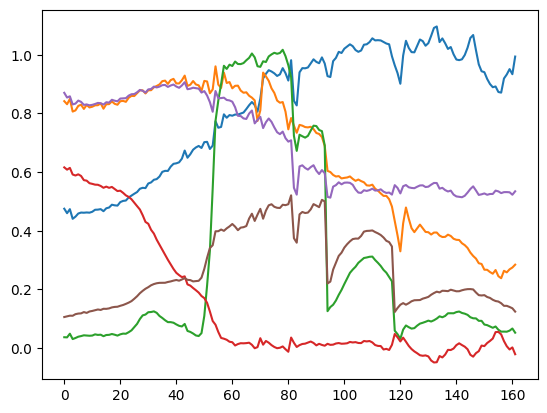

In [35]:
model = unmixer
model = models.init_decoder_weights(model, Y, c, is_unmixer=True, use_sivm=True)
print("The unmixer model has : ", sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6, "M params")
E_hat, A_hat, Y_hat = model(features)
plt.plot(E_hat.detach().cpu())

Epoch 0: total = 0.840, SAD = 0.426, Ab = 0.360, TV = 347.197, MSE = 0.996
Epoch 20: total = 0.625, SAD = 0.210, Ab = 0.367, TV = 327.667, MSE = 0.995
Epoch 40: total = 0.578, SAD = 0.173, Ab = 0.349, TV = 310.176, MSE = 0.995
Epoch 60: total = 0.534, SAD = 0.141, Ab = 0.328, TV = 304.268, MSE = 0.995
Epoch 80: total = 0.507, SAD = 0.122, Ab = 0.311, TV = 307.739, MSE = 0.995
Epoch 100: total = 0.493, SAD = 0.114, Ab = 0.297, TV = 306.627, MSE = 0.995
Epoch 120: total = 0.484, SAD = 0.112, Ab = 0.286, TV = 303.525, MSE = 0.995
Epoch 140: total = 0.477, SAD = 0.110, Ab = 0.276, TV = 301.875, MSE = 0.995
Epoch 160: total = 0.471, SAD = 0.109, Ab = 0.267, TV = 300.367, MSE = 0.995
Epoch 180: total = 0.468, SAD = 0.109, Ab = 0.260, TV = 299.086, MSE = 0.995
Epoch 200: total = 0.464, SAD = 0.108, Ab = 0.253, TV = 298.791, MSE = 0.995
Epoch 220: total = 0.461, SAD = 0.108, Ab = 0.247, TV = 298.358, MSE = 0.995
Epoch 240: total = 0.457, SAD = 0.107, Ab = 0.242, TV = 298.632, MSE = 0.995
Epoch

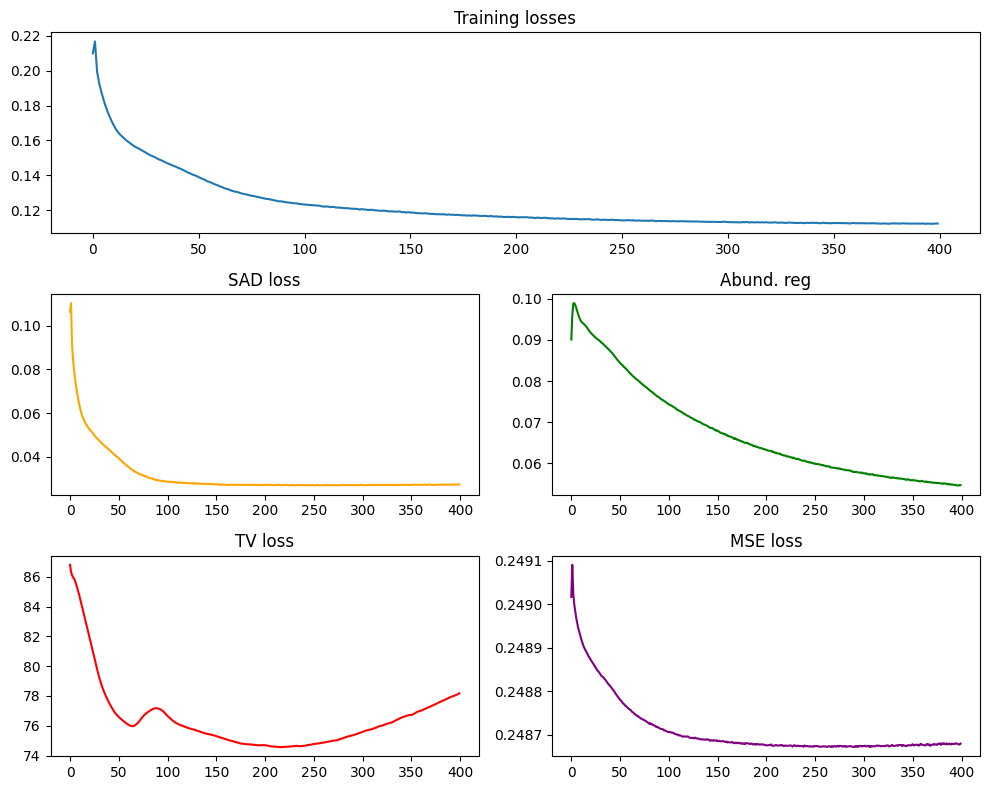

In [ ]:
train_losses, sad_losses, ab_losses, tv_losses, mse_losses = [], [], [], [], []
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev)

epochs, lr = 400, 0.01
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
for epoch in range(epochs):
    
    train_loss, sad_loss, ab_loss, tv_loss, mse_loss = 0, 0, 0, 0, 0
    
    for Y, E, A in loader:
        optimizer.zero_grad()
        
        Y = utils.oneD_to_2d(Y).to(dev)
        A = utils.oneD_to_2d(A).to(dev)
        E = E.to(dev)

        if fm_name == "DOFA":
            if Y.shape[-1] < 224:
                Y = F.interpolate(Y, size=(224,224))
            Y = Y[:,:,:224, :224]
            Y_flat = Y.reshape(1, B, 224**2)
            
            if A.shape[-1] < 224:
                A = F.interpolate(A, size=(224,224))
            A = A[:,:,:224, :224]
            A_flat = A.reshape(1, c, 224**2)

            features = rsfm.get_dofa_features(fm, Y, wavelengths)
            noise = torch.rand_like(features)
            E_hat, A_hat, Y_hat = model(features)

        elif fm_name == "HyperFree":
            features = rsfm.get_hyperfree_features(fm, Y, wavelengths)
            noise = torch.rand_like(features)
            E_hat, A_hat, Y_hat = model(features)

        elif fm_name == "HyperSIGMA":
            E_hat, A_hat, Y_hat = rsfm.unmix_full_image_hypersigma(Y, model, fm, c)
            
        else:
            pass
        
        W_sad, W_ab, W_tv, W_mse = 1, 0.5, 1e-4, 0.2
        loss, loss_sad, loss_ab, loss_tv, loss_mse = model.loss(Y, Y_hat, A_hat, E_hat, W_sad=W_sad, W_ab=W_ab, W_tv=W_tv, W_mse=W_mse)
        train_loss += loss.item()
        sad_loss += loss_sad.item()
        ab_loss += loss_ab.item()
        tv_loss += loss_tv.item()
        mse_loss += loss_mse.item()

        if epoch%(epochs//20)==0:
            print(f"Epoch {epoch}: total = {format(loss, '.3f')}, SAD = {format(loss_sad, '.3f')}, Ab = {format(loss_ab, '.3f')}, TV = {format(loss_tv, '.3f')}, MSE = {format(loss_mse, '.3f')}")
        
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
        break

    train_loss /= len(loader)
    sad_loss /= len(loader)
    ab_loss /= len(loader)
    tv_loss /= len(loader)
    mse_loss /= len(loader)
    train_losses.append(train_loss)
    sad_losses.append(sad_loss)
    ab_losses.append(ab_loss)
    tv_losses.append(tv_loss)
    mse_losses.append(mse_loss)
utils.plot_losses(train_losses, sad_losses, ab_losses, tv_losses, mse_losses)
# plt.plot(train_losses)
# plt.title('Training loss')
# plt.show()

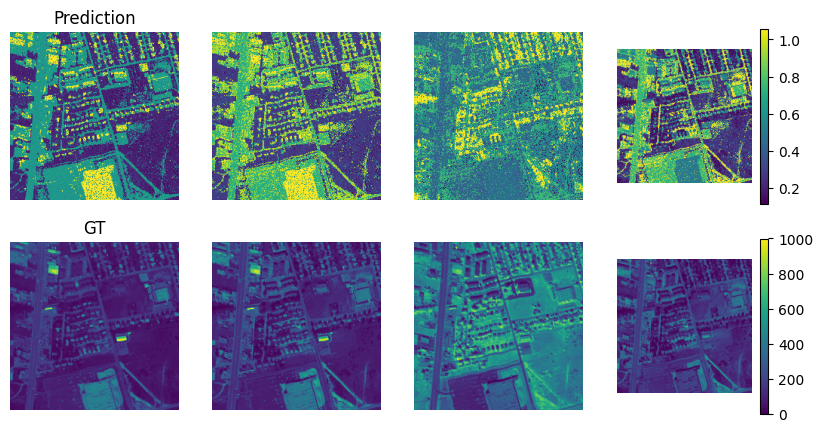

In [37]:
if model.__class__.__name__ == "DeepTransDOFA" or model.__class__.__name__ == "DeepTrans":
    Y_hat = utils.oneD_to_2d(Y_hat)

utils.compare_hsis(Y, Y_hat)
# plt.imshow(F.interpolate(Y_hat, size=(2000,2000))[0,0].detach().cpu())
# plt.axis("off")
# plt.title("Reconstructed HSI")

Not taking batched E_gt
Not taking batched A_hat
Not taking batched A_gt
SAD(E, E_hat) = 0.186
NMSE(A, A_hat) = 0.540


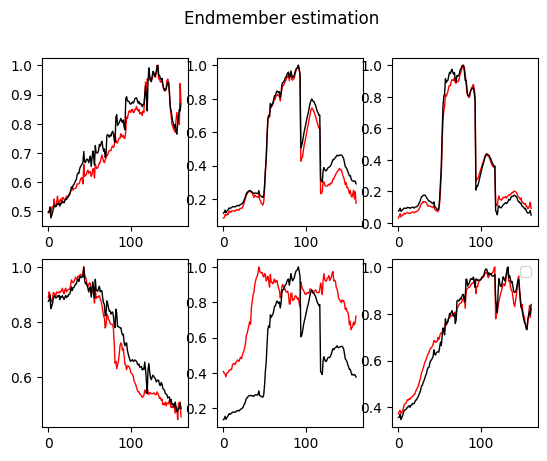

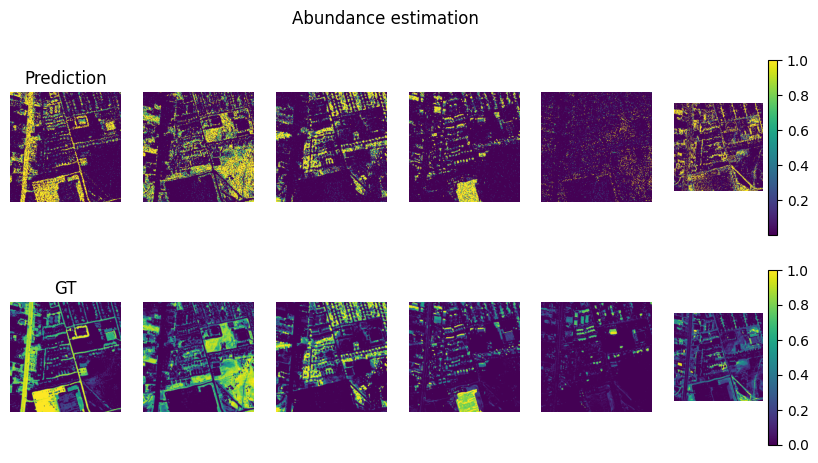

In [38]:
# if model.__class__.__name__ == "DeepTrans":
#     E_hat, A_hat, Y_hat = model(Y)
#     Y_hat = utils.oneD_to_2d(Y_hat)
#     A_hat = utils.oneD_to_2d(A_hat)
# else:
#     E_hat, A_hat, Y_hat = model(features)
# if model.__class__.__name__ == "DeepTransDOFA":
#     A_hat = utils.oneD_to_2d(A_hat)
if fm_name == "DOFA":
    E_hat, A_hat, Y_hat = model(features)
elif fm_name == "HyperFree":
    E_hat, A_hat, Y_hat = model(features)
else:
    E_hat, A_hat, Y_hat = rsfm.unmix_full_image_hypersigma(Y, model, fm, c, patch_size=patch_size)
utils.plot_results(E_hat, A_hat, A, E, normalize_E=True, normalize_A=True)

In [ ]:
sys.path.append("/home/ids/edabier/HSU/IEEE_TPAMI_SpectralGPT")
import models_mae_spectral

torch.serialization.add_safe_globals([argparse.Namespace])
state_dict = torch.load("/home/ids/edabier/HSU/IEEE_TPAMI_SpectralGPT/data/SpectralGPT+.pth", map_location=dev)["model"]

img_size = 128
spectral_gpt = models_mae_spectral.mae_vit_base_patch8_128(num_frames=Y.shape[0], pred_t_dim=Y.shape[0])
# spectral_gpt = models_mae_spectral.__dict__[f"mae_vit_base_patch{patch_size}_{img_size}"]()

encoder_keys = [k for k in state_dict.keys() if k.startswith('patch_embed') or k.startswith('blocks') or k.startswith('norm')]
encoder_state_dict = {k: state_dict[k] for k in encoder_keys}
spectral_gpt.load_state_dict(encoder_state_dict, strict=False)

y_patch = Y.unsqueeze(0)[:,:,:img_size,:img_size]
# y_patch = y_patch.reshape(Y.shape[0], 1, img_size, img_size)
# print(y_patch.shape)
# y_patch = y_patch.reshape(y_patch.shape[0], y_patch[2], y_patch[1], y_patch[3])
latent, _, _ = spectral_gpt.forward_encoder(y_patch, mask_ratio=0.0)

img_size (128, 128) patch_size (8, 8) frames 162 t_patch_size 3
model initialized
torch.Size([1, 1, 162, 128, 128])
torch.Size([1, 1, 162, 128, 128])


OutOfMemoryError: CUDA out of memory. Tried to allocate 8.54 GiB. GPU 0 has a total capacity of 15.89 GiB of which 5.26 GiB is free. Including non-PyTorch memory, this process has 10.63 GiB memory in use. Of the allocated memory 10.19 GiB is allocated by PyTorch, and 150.28 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
sys.path.append("/home/ids/edabier/HSU/HyperFree")
from HyperFree import build_HyperFree_vit_b, predictor

pred = build_HyperFree_vit_b(checkpoint="/home/ids/edabier/HSU/HyperFree/data/HyperFree-b.pth", image_size=batched_Y.shape[2], vit_patch_size=patch_size)
hyperfree = predictor.HyperFree_Predictor(pred)

input_y = hyperfree.transform.apply_image_torch(batched_Y)
hyperfree.set_torch_image(input_y, original_image_size=(Y.shape[1], Y.shape[2]), spectral_lengths=wavelengths, GSD=GSD)
hyperfree.features.shape